# Discrete-time simulation of a silicon-photonic WDM link with four-wave mixing

This notebook simulates a four-channel, 10 Gb/s wavelength-division-multiplexed (WDM) link end to end in Simphony's **block-mode** simulator:

* **Transmitter (silicon photonics):** four lasers, electro-absorption-style modulators driven by PRBS7 data, and a **SiEPIC microring multiplexer** (EBeam `half_ring` + `waveguide` models) that adds each channel onto one bus waveguide.
* **Link:** 20 km of single-mode fiber, solved with a **split-step Fourier (SSFM)** nonlinear Schrödinger solver that carries all channels *and* their four-wave-mixing (FWM) products.
* **Receiver (silicon photonics):** a **SiEPIC microring demultiplexer**, photodiodes with thermal noise, and a sampled digital decision (eye diagrams, Q factor, error counts).

The physics question is a classic one: **equally spaced WDM channels on dispersion-shifted fiber (DSF) generate FWM products that land exactly on the other channels**, so raising the launch power eventually *degrades* the link, while non-zero-dispersion-shifted fiber (NZ-DSF) suppresses FWM by phase mismatch [Tkach 1995; Forghieri 1995].

The simulation question is the reason this notebook exists: **what does a discrete-time simulator make practical that a continuous-time circuit solver does not?** Section 1 summarizes the answer; the rest of the notebook demonstrates it. The custom components (fiber, photodiode, burst laser, PRBS driver) are defined inside this notebook so they can be reviewed in one place; everything else is native Simphony.

> **Runtime:** about 10 minutes on a laptop CPU, dominated by the 13 end-to-end link simulations in Section 7 (each about 20-35 s, including vector-fitting eight rings).

## 1. Discrete time vs. continuous time for photonic circuits

**Circulax** ([gdsfactory/circulax](https://github.com/gdsfactory/circulax)) is a differentiable JAX circuit simulator. It treats a netlist as a differential-algebraic system $F(y) + \tfrac{d}{dt}Q(y) = 0$ and integrates it with implicit, A-stable steppers (trapezoidal by default; BDF2, SDIRK3), solving a Newton system at every step, with optional adaptive step control ([transient docs](https://gdsfactory.github.io/circulax/)). Photonic signals are complex envelopes on the node variables. It has grown substantially: it now includes **vector fitting to continuous-time pole-residue models, delay inference, and passivity enforcement**, plus **exact propagation delays** that read interpolated history (`signals.at_delay(tau)`). So "circulax cannot convert frequency-domain data to the time domain" is no longer accurate. The meaningful differences are structural:

| | Simphony block/sample mode (discrete time) | Circulax transient (continuous time) |
|---|---|---|
| Time axis | fixed sample period $\Delta t$; every signal is a sampled sequence | continuous $t$; the solver picks the steps |
| Frequency-domain models | fitted directly in $z$; one sample is one exact recurrence step (no truncation error, no Newton iteration) | fitted in $s$ (continuous poles), then integrated with a trapezoidal/BDF/SDIRK rule plus Newton at every step |
| Component interface | a component may act on the **whole block** (FFTs, filters, DSP, split-step propagation) | a component returns residuals at the current time, and may read delayed history; it cannot see a future or whole window |
| Optical carriers | each signal carries **several baseband carriers** (the WDM channels); one fitted model serves them all by rotating its poles | one complex envelope per component around a fixed `wavelength_nm` carrier |
| Natural strengths | open-loop links, dispersion/nonlinear propagation, WDM, receivers/DSP, long bit sequences | stiff mixed-signal electronics, DC/AC/harmonic-balance analysis, gradients through the solver |

This is the same split the commercial tools make. Lumerical INTERCONNECT's transient solver is a *sample-mode/block-mode* simulator whose optical signals carry "an arbitrary number of modes and basebands" ([Ansys docs](https://optics.ansys.com/hc/en-us/articles/360034399174-INTERCONNECT-Transient-Sample-Block-Mode-TSM-TBM-Simulator)), and fiber-system tools such as VPItransmissionMaker are built around sampled blocks and split-step solvers.

**Why this link is the right test case.** It needs three things at once:

1. **Distributed Kerr nonlinearity interleaved with dispersion.** Section 5 shows that even the *linear* part of this fiber needs a rational model whose order grows with the delay-spread x bandwidth product. At the full WDM bandwidth it is beyond a 300th-order fit, and the Kerr term has to be applied inside the fiber, not at its ends. The split-step method solves exactly this, with two FFTs per step. Those FFTs act on the whole sampled block, which only a block-mode component can do.
2. **Several carriers that interact.** FWM couples the channels, so they cannot be simulated one carrier at a time. Simphony's multi-carrier signals keep each channel near its own baseband, while the fiber recombines them for the nonlinear step.
3. **Silicon photonic filters with memory.** The microring (de)multiplexers are feedback loops. A fused SAX ring fitted once in the $z$-domain becomes a single stable IIR filter that serves all six carriers.

Discrete time also has a price, and this notebook pays it explicitly:
* the carrier grid must be commensurate with the block length (the block is periodic);
* sources must be band-limited, with guard intervals;
* fitted models must only ever be driven inside the band they were fitted over.

Section 6 explains why, with a measurement.

## 2. Setup and signal grid

Six baseband carriers on a 200 GHz grid are tracked: four data channels (193.3-193.9 THz) plus one empty "idler" slot on each side (193.1 and 194.1 THz). The idler slots catch the FWM products that fall just outside the channel band.

* **Sample period** $\Delta t = 0.5$ ps, so the sampling rate $f_s = 2$ THz spans the whole WDM band plus FWM products. The fiber recombines all carriers into a single wideband field, so this must hold.
* **Block length** $T = 127$ bits (one PRBS7 period) at 10 Gb/s = 12.7 ns = 25 400 samples.
* **Commensurate grid:** every carrier offset times the block length is a whole number of cycles, $\Delta f \cdot T\Delta t \in \mathbb{Z}$. The block is then exactly periodic, which the circular FFTs inside the fiber require.

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import sax
from scipy.constants import c as C0
from scipy.optimize import minimize_scalar
from scipy.special import erfc

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", message="Could not validate netlist")

from simphony.circuit.circuit import Circuit
from simphony.component.component import BlockModeComponent
from simphony.component.port import Port
from simphony.libraries.ideal.modulators import DirectedOpticalModulator
from simphony.libraries.ideal.s_parameters import optical_s_parameter
from simphony.libraries.ideal.sources import CWLaser, VoltageSource
from simphony.libraries.siepic import half_ring, waveguide
from simphony.signal.block_mode import BlockModeElectricalSignal, BlockModeOpticalSignal
from simphony.simulation.block_mode import BlockModeSimulation, BlockModeSimulationParameters
from simphony.time_domain.vector_fitting.z_domain import (
    PHYSICIST,
    pole_residue_response_discrete,
    vector_fitting_discrete,
)

# Categorical colours (validated for colour-vision deficiency); gray is reserved for references.
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
CHANNEL_COLORS = [BLUE, ORANGE, AQUA, YELLOW]
GRAY = "#6b6b66"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2})

timings = {}

In [2]:
F_CENTER = 193.6e12            # reference carrier of the fiber and of every z-domain fit (Hz)
SPACING = 200e9                # WDM grid (Hz)
SLOT_FREQS = F_CENTER + SPACING * np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5])
CHANNEL_FREQS = SLOT_FREQS[1:5]
WL_SLOTS = C0 / SLOT_FREQS     # tracked baseband wavelengths (m)
CHANNEL_SLOTS = [1, 2, 3, 4]   # index of each data channel in the tracked-carrier axis

BIT_RATE = 10e9
N_BITS = 127                   # one PRBS7 period
DT = 0.5e-12
SAMPLES_PER_BIT = int(round(1 / (BIT_RATE * DT)))
T = N_BITS * SAMPLES_PER_BIT
BLOCK = T * DT

cycles = (SLOT_FREQS - F_CENTER) * BLOCK
assert np.allclose(cycles, np.round(cycles)), "carrier grid must be commensurate with the block"
print(f"{T} samples, {SAMPLES_PER_BIT} samples/bit, block {BLOCK*1e9:.1f} ns, f_s = {1/DT/1e12:.1f} THz")
print("tracked carriers (THz):", np.round(SLOT_FREQS / 1e12, 3), " (data channels: slots 1-4)")

params = BlockModeSimulationParameters(
    dt=DT,
    num_time_steps=T,
    optical_baseband_wavelengths=jnp.asarray(WL_SLOTS),
    mode_identifiers=("te",),
)

25400 samples, 200 samples/bit, block 12.7 ns, f_s = 2.0 THz
tracked carriers (THz): [193.1 193.3 193.5 193.7 193.9 194.1]  (data channels: slots 1-4)


## 3. Notebook-local components

Everything not in Simphony's libraries is defined here:

| component | kind | why it is custom |
|---|---|---|
| `nrz_envelope_fn` | waveform for Simphony's native `VoltageSource(envelope_fn=...)` | PRBS data through a Gaussian (band-limited) driver |
| `BurstCWLaser` | subclass of Simphony's native `CWLaser` | sets the power and emits a smooth burst with dark guard intervals (Section 6 explains why) |
| `SplitStepFiber` | new `BlockModeComponent` | multi-carrier nonlinear Schrödinger equation (loss, $\beta_2$, $\beta_3$, Kerr), solved with symmetric split-step Fourier |
| `Photodetector` | new `BlockModeComponent` | square law, thermal noise, and a Gaussian electrical low-pass |

The modulators are Simphony's `DirectedOpticalModulator`, used as an electro-absorption modulator: absorption in dB is a polynomial in drive voltage. The rings are SiEPIC models wrapped by `optical_s_parameter`.

In [3]:
def prbs(order=7, n_bits=127, seed=1):
    # Maximal-length pseudo-random bit sequence from a Fibonacci LFSR.
    taps = {7: (7, 6), 9: (9, 5), 11: (11, 9), 15: (15, 14)}[order]
    state = [(seed >> i) & 1 for i in range(order)]
    if not any(state):
        state[0] = 1
    bits = []
    for _ in range(n_bits):
        bits.append(state[-1])
        state = [state[taps[0] - 1] ^ state[taps[1] - 1]] + state[:-1]
    return np.array(bits, dtype=int)


def nrz_envelope_fn(bits, bit_rate, bandwidth):
    # NRZ 0/1 levels through a Gaussian low-pass of 3 dB `bandwidth` (a band-limited
    # driver). Returns an envelope_fn(t) for simphony's VoltageSource. The waveform is
    # periodic in the pattern, matching the periodic block.
    bits = np.asarray(bits, dtype=float)

    def envelope_fn(t):
        t = np.asarray(t)
        raw = bits[np.floor(t * bit_rate + 1e-9).astype(int) % len(bits)]
        f = np.fft.fftfreq(len(t), t[1] - t[0])
        H = np.exp(-np.log(2) / 2 * (f / bandwidth) ** 2)
        v = np.real(np.fft.ifft(np.fft.fft(raw) * H))
        return BlockModeElectricalSignal(voltage=jnp.asarray(v, dtype=complex))

    return envelope_fn


class BurstCWLaser(CWLaser):
    # Simphony's CWLaser, with a power setting and a smooth burst envelope.
    #
    # The output is dark for `guard_time` at both ends of the block and ramps on/off
    # with raised-cosine edges of `rise_time`. An instantaneous turn-on is a broadband
    # step whose spectrum reaches the edge of the Nyquist zone, where fitted z-domain
    # models are not constrained by any data. The dark guards (longer than the fiber's
    # dispersive walk-off) mean the periodic fiber only wraps darkness across t = 0, so
    # every downstream IIR filter starts from rest with zero input.

    def __init__(self, simulation_parameters, *, power=1e-3, rise_time=200e-12,
                 guard_time=1e-9, **kwargs):
        super().__init__(simulation_parameters, **kwargs)
        self.power, self.rise_time, self.guard_time = power, rise_time, guard_time

    def block_mode_response(self, inputs, simulation_parameters):
        out = super().block_mode_response(inputs, simulation_parameters)["o0"]
        t = jnp.arange(simulation_parameters.num_time_steps) * simulation_parameters.dt
        up = jnp.clip((t - self.guard_time) / self.rise_time, 0, 1)
        down = jnp.clip((t[-1] - self.guard_time - t) / self.rise_time, 0, 1)
        ramp = (0.5 - 0.5 * jnp.cos(jnp.pi * up)) * (0.5 - 0.5 * jnp.cos(jnp.pi * down))
        amplitude = out.amplitude * (jnp.sqrt(self.power) * ramp)[:, None, None]
        return {"o0": out.replace(amplitude=amplitude)}

### The split-step fiber

The block-mode signal carries one complex envelope per tracked carrier, $A_l(t)$ at frequency $f_l$. The fiber:

1. **recombines** the carriers into one wideband envelope around $f_\text{ref}$: $E(t) = \sum_l A_l(t)\,e^{-i\Delta\omega_l t}$ (Simphony's physicist convention, $e^{-i\omega t}$);
2. **propagates** $E$ through the scalar NLSE in the retarded frame [Agrawal, *Nonlinear Fiber Optics*]:
$$\frac{\partial E}{\partial z} = -\frac{\alpha}{2}E - \frac{i\beta_2}{2}\frac{\partial^2 E}{\partial t^2} + \frac{\beta_3}{6}\frac{\partial^3 E}{\partial t^3} + i\gamma |E|^2 E,$$
   using symmetric split steps. The linear half-step is applied in the frequency domain, $\tilde E \leftarrow \tilde E\, e^{(i\beta(\omega) - \alpha/2)h/2}$ with $\beta(\omega) = \tfrac{\beta_2}{2}\omega^2 + \tfrac{\beta_3}{6}\omega^3$. The Kerr step is applied in time, $E \leftarrow E\,e^{i\gamma|E|^2 h_\text{eff}}$;
3. **splits** the result back onto the carriers with raised-cosine weights centered on each carrier. These weights form a partition of unity on a uniform grid, so each envelope stays band-limited to ±1 spacing, and FWM products that fall on a tracked carrier end up in that channel.

**Step size** is the smaller of two limits:
* the nonlinear phase per step (≤ 0.01 rad);
* the FWM phase mismatch per step, $|\Delta\beta|\,h \le 0.2$ rad, over every degenerate process $2\omega_i - \omega_k$ that lands on a tracked carrier.

A fixed step longer than the FWM coherence length creates *spurious* FWM, which is a known split-step artifact [Bosco 2000]. The validation in Section 4 shows what happens at D = 17 ps/nm/km without the second limit.

In [4]:
class SplitStepFiber(BlockModeComponent):
    ports = [
        Port(name="o0", type="optical", directionality="input"),
        Port(name="o1", type="optical", directionality="output"),
    ]

    def __init__(self, simulation_parameters, *, length_km=20.0, alpha_db_km=0.2,
                 D_ps_nm_km=17.0, S_ps_nm2_km=0.07, gamma_W_km=1.3,
                 reference_wavelength=1.55e-6, max_phase_step=0.01,
                 max_walkoff_phase=0.2, min_steps=20):
        lam = reference_wavelength
        D = D_ps_nm_km * 1e-6                     # s / m^2
        S = S_ps_nm2_km * 1e3                     # s / m^3
        self.beta2 = -D * lam**2 / (2 * np.pi * C0)                      # s^2 / m
        self.beta3 = (lam**2 / (2 * np.pi * C0)) ** 2 * (S + 2 * D / lam)  # s^3 / m
        self.alpha = alpha_db_km / (10 * np.log10(np.e)) / 1e3           # 1 / m (power)
        self.gamma = gamma_W_km / 1e3                                    # 1 / (W m)
        self.length = length_km * 1e3
        self.f_ref = C0 / reference_wavelength
        self.max_phase_step, self.max_walkoff_phase = max_phase_step, max_walkoff_phase
        self.min_steps = min_steps

    def beta(self, w):
        # propagation constant relative to the reference carrier and group delay (rad/m)
        return self.beta2 / 2 * w**2 + self.beta3 / 6 * w**3

    def n_steps(self, peak_power, dw_carriers):
        if self.gamma == 0:
            return 1  # purely linear: a single step is exact
        l_eff = (1 - np.exp(-self.alpha * self.length)) / self.alpha
        n_nl = np.ceil(self.gamma * peak_power * l_eff / self.max_phase_step)
        dw = np.asarray(dw_carriers, dtype=float)
        dbeta = [0.0]
        if dw.size > 1:
            spacing = np.min(np.diff(np.sort(dw)))
            for wi in dw:
                for wk in dw:
                    w_idler = 2 * wi - wk
                    if wi != wk and np.min(np.abs(dw - w_idler)) < spacing / 2:
                        dbeta.append(abs(self.beta(wk) + self.beta(w_idler) - 2 * self.beta(wi)))
        n_wo = np.ceil(max(dbeta) * self.length / self.max_walkoff_phase)
        return int(max(self.min_steps, n_nl, n_wo))

    def propagate(self, E, dt, dw_carriers):
        n = self.n_steps(float(jnp.max(jnp.abs(E) ** 2)), dw_carriers)
        self.last_n_steps = n
        h = self.length / n
        w = 2 * jnp.pi * jnp.fft.fftfreq(E.shape[0], dt)
        half_linear = jnp.exp((1j * self.beta(w) - self.alpha / 2) * h / 2)
        h_eff = (1 - np.exp(-self.alpha * h)) / self.alpha if self.alpha > 0 else h
        gamma = self.gamma

        def step(_, E):
            E = jnp.fft.fft(jnp.fft.ifft(E) * half_linear)   # spectrum S = ifft(E) (e^{-i w t})
            E = E * jnp.exp(1j * gamma * jnp.abs(E) ** 2 * h_eff)
            return jnp.fft.fft(jnp.fft.ifft(E) * half_linear)

        return jax.lax.fori_loop(0, n, step, E)

    def block_mode_response(self, inputs, simulation_parameters):
        signal = inputs["o0"]
        A, wls = signal.amplitude, signal.wavelength          # (T, L, M), (L,)
        T_, L, _ = A.shape
        dt = simulation_parameters.dt
        t = jnp.arange(T_) * dt
        dw = 2 * jnp.pi * (C0 / wls - self.f_ref)
        cycles = np.asarray(dw) / (2 * np.pi) * T_ * dt
        if np.max(np.abs(cycles - np.round(cycles))) > 1e-3:
            warnings.warn("SplitStepFiber: carriers are not commensurate with the block; "
                          "CW carriers will leak spectrally into other channels.")

        E = jnp.sum(A[:, :, 0] * jnp.exp(-1j * dw[None, :] * t[:, None]), axis=1)  # mode 0: scalar fiber
        self.last_input_field = np.asarray(E)
        E = self.propagate(E, dt, np.asarray(dw))
        self.last_output_field = np.asarray(E)

        w = 2 * jnp.pi * jnp.fft.fftfreq(T_, dt)
        if L > 1:
            spacing = np.min(np.diff(np.sort(np.asarray(dw))))
            x = jnp.clip(jnp.abs(w[:, None] - dw[None, :]) / spacing, 0, 1)
            weights = 0.5 + 0.5 * jnp.cos(jnp.pi * x)                                # (T, L)
        else:
            weights = jnp.ones((T_, 1))                                              # one carrier keeps everything
        S = jnp.fft.ifft(E)
        self.discarded_energy_fraction = float(
            1 - jnp.sum(jnp.abs(S[:, None] * weights) ** 2) / jnp.sum(jnp.abs(S) ** 2))
        out = jnp.zeros(A.shape, dtype=complex)
        for l in range(L):
            out = out.at[:, l, 0].set(jnp.fft.fft(S * weights[:, l]) * jnp.exp(1j * dw[l] * t))
        return {"o1": BlockModeOpticalSignal(amplitude=out, wavelength=wls)}


class Photodetector(BlockModeComponent):
    # Square-law detection of every carrier and mode, input-referred white thermal noise
    # (A/sqrt(Hz)), then a Gaussian low-pass with 3 dB `bandwidth`. Beat notes between
    # carriers (>= 200 GHz) are far outside the electrical bandwidth, so they are omitted.
    ports = [
        Port(name="o0", type="optical", directionality="input"),
        Port(name="e0", type="electrical", directionality="output"),
    ]

    def __init__(self, simulation_parameters, *, responsivity=1.0, bandwidth=7.5e9,
                 noise_density=20e-12, seed=0):
        self.responsivity, self.bandwidth = responsivity, bandwidth
        self.noise_density, self.seed = noise_density, seed

    def block_mode_response(self, inputs, simulation_parameters):
        A, dt = inputs["o0"].amplitude, simulation_parameters.dt
        T_ = A.shape[0]
        current = self.responsivity * jnp.sum(jnp.abs(A) ** 2, axis=(1, 2))
        noise = jax.random.normal(jax.random.PRNGKey(self.seed), (T_,))
        current = current + self.noise_density * jnp.sqrt(1 / (2 * dt)) * noise
        f = jnp.fft.fftfreq(T_, dt)
        H = jnp.exp(-np.log(2) / 2 * (f / self.bandwidth) ** 2)
        return {"e0": BlockModeElectricalSignal(voltage=jnp.real(jnp.fft.ifft(jnp.fft.fft(current) * H)))}

## 4. Validating the fiber against closed-form results

The fiber runs standalone here, by calling `block_mode_response` directly on a 10 ns block, against three analytic references:

* **Dispersion only:** a Gaussian pulse broadens as $T_1 = T_0\sqrt{1 + (L/L_D)^2}$, with $L_D = T_0^2/|\beta_2|$, and conserves energy exactly.
* **Self-phase modulation:** a CW input acquires a nonlinear phase $\gamma P L_\text{eff}$.
* **FWM efficiency:** two CW pumps at $f_1, f_2$ produce an idler at $2f_1 - f_2$ with power [Inoue 1992]
$$P_\text{idler} = (\gamma L_\text{eff})^2 P_1^2 P_2\, e^{-\alpha L}\,\eta, \qquad \eta = \frac{\alpha^2}{\alpha^2 + \Delta\beta^2}\left[1 + \frac{4e^{-\alpha L}\sin^2(\Delta\beta L/2)}{(1-e^{-\alpha L})^2}\right], \qquad \Delta\beta = \frac{2\pi\lambda^2}{c}\,\Delta f^2 D.$$

In [5]:
def run_fiber(fiber, amplitudes, freqs, dt=DT, n=20000):
    # Run a SplitStepFiber standalone on CW/pulse envelopes (n x carriers).
    sp = BlockModeSimulationParameters(dt=dt, num_time_steps=n, mode_identifiers=("te",),
                                       optical_baseband_wavelengths=jnp.asarray(C0 / np.asarray(freqs)))
    sig = BlockModeOpticalSignal(amplitude=jnp.asarray(amplitudes)[:, :, None],
                                 wavelength=jnp.asarray(C0 / np.asarray(freqs)))
    return np.asarray(fiber.block_mode_response({"o0": sig}, sp)["o1"].amplitude[:, :, 0])


LAM_REF = C0 / F_CENTER
n = 20000
t = np.arange(n) * DT

# (a) linear dispersion of a Gaussian pulse (SSMF, 20 km)
T0 = 5e-12
pulse = np.exp(-((t - t[n // 2]) ** 2) / (2 * T0**2)).astype(complex)[:, None]
fib = SplitStepFiber(None, length_km=20, alpha_db_km=0, D_ps_nm_km=17, S_ps_nm2_km=0,
                     gamma_W_km=0, reference_wavelength=LAM_REF)
out = run_fiber(fib, pulse, [F_CENTER])
p = np.abs(out[:, 0]) ** 2
t_mean = np.sum(t * p) / np.sum(p)
T1 = np.sqrt(2 * np.sum((t - t_mean) ** 2 * p) / np.sum(p))
T1_expected = T0 * np.sqrt(1 + (fib.length * abs(fib.beta2) / T0**2) ** 2)
print(f"dispersion: rms-width T1 = {T1*1e12:.3f} ps (analytic {T1_expected*1e12:.3f} ps), "
      f"energy ratio {np.sum(p) / np.sum(np.abs(pulse) ** 2):.6f}")

# (b) self-phase modulation of a CW carrier
P = 0.05
fib = SplitStepFiber(None, length_km=10, alpha_db_km=0.2, D_ps_nm_km=0, S_ps_nm2_km=0,
                     gamma_W_km=2.0, reference_wavelength=LAM_REF)
out = run_fiber(fib, np.sqrt(P) * np.ones((n, 1), complex), [F_CENTER])
l_eff = (1 - np.exp(-fib.alpha * fib.length)) / fib.alpha
print(f"SPM: nonlinear phase {np.angle(out[100, 0]):.4f} rad (analytic {fib.gamma * P * l_eff:.4f} rad)")

dispersion: rms-width T1 = 86.709 ps (analytic 86.709 ps), energy ratio 1.000000


SPM: nonlinear phase 0.7991 rad (analytic 0.8014 rad)


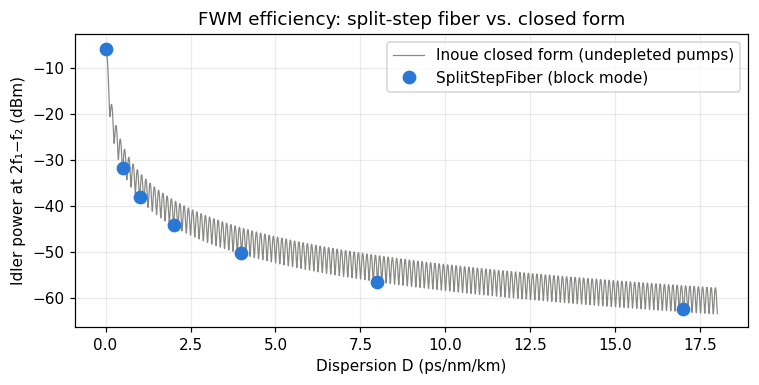

D =  0.0: simulated   -5.87 dBm, analytic   -5.55 dBm  (119 split steps)
D =  0.5: simulated  -31.69 dBm, analytic  -32.33 dBm  (126 split steps)
D =  1.0: simulated  -37.94 dBm, analytic  -38.35 dBm  (252 split steps)
D =  2.0: simulated  -44.12 dBm, analytic  -44.37 dBm  (504 split steps)
D =  4.0: simulated  -50.28 dBm, analytic  -50.38 dBm  (1007 split steps)
D =  8.0: simulated  -56.37 dBm, analytic  -56.39 dBm  (2013 split steps)
D = 17.0: simulated  -62.44 dBm, analytic  -62.88 dBm  (4277 split steps)


In [6]:
# (c) FWM idler power vs dispersion: two 10 dBm pumps 200 GHz apart, 25 km, gamma = 2 /W/km
pump_freqs = np.array([193.5e12, 193.7e12, 193.3e12, 193.9e12])   # pump 1, pump 2, idler slots
P1 = P2 = 0.01
L_km, alpha_db, gamma = 25.0, 0.2, 2.0


def fwm_analytic(D):
    fib = SplitStepFiber(None, length_km=L_km, alpha_db_km=alpha_db, D_ps_nm_km=D, S_ps_nm2_km=0,
                         gamma_W_km=gamma, reference_wavelength=LAM_REF)
    a, Lm = fib.alpha, fib.length
    leff = (1 - np.exp(-a * Lm)) / a
    dbeta = 2 * np.pi * LAM_REF**2 / C0 * (pump_freqs[0] - pump_freqs[1]) ** 2 * (np.asarray(D) * 1e-6)
    eta = a**2 / (a**2 + dbeta**2) * (1 + 4 * np.exp(-a * Lm) * np.sin(dbeta * Lm / 2) ** 2
                                     / (1 - np.exp(-a * Lm)) ** 2)
    return (fib.gamma * leff) ** 2 * P1**2 * P2 * np.exp(-a * Lm) * eta


D_sim = np.array([0.0, 0.5, 1.0, 2.0, 4.0, 8.0, 17.0])
idler_sim, steps = [], []
tic = time.time()
for D in D_sim:
    A = np.zeros((n, 4), complex)
    A[:, 0], A[:, 1] = np.sqrt(P1), np.sqrt(P2)
    fib = SplitStepFiber(None, length_km=L_km, alpha_db_km=alpha_db, D_ps_nm_km=D, S_ps_nm2_km=0,
                         gamma_W_km=gamma, reference_wavelength=LAM_REF)
    out = run_fiber(fib, A, pump_freqs)
    idler_sim.append(np.mean(np.abs(out[n // 4: 3 * n // 4, 2]) ** 2))
    steps.append(fib.last_n_steps)
timings["FWM validation (7 fiber runs)"] = time.time() - tic

D_dense = np.linspace(0, 18, 20001)   # the sin^2 term oscillates quickly in D; sample it densely
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(D_dense, 10 * np.log10(fwm_analytic(D_dense)) + 30, color=GRAY, lw=0.8, alpha=0.8,
        label="Inoue closed form (undepleted pumps)")
ax.plot(D_sim, 10 * np.log10(idler_sim) + 30, "o", color=BLUE, ms=8,
        label="SplitStepFiber (block mode)")
ax.set(xlabel="Dispersion D (ps/nm/km)", ylabel="Idler power at 2f₁−f₂ (dBm)",
       title="FWM efficiency: split-step fiber vs. closed form")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
for D, P_i, s in zip(D_sim, idler_sim, steps):
    print(f"D = {D:4.1f}: simulated {10*np.log10(P_i)+30:7.2f} dBm, analytic {10*np.log10(fwm_analytic(D))+30:7.2f} dBm  ({s} split steps)")

Agreement is within about 0.6 dB from D = 0 (a phase-matched −6 dBm idler) down to D = 17 ps/nm/km (a −62 dBm idler). The small discrepancy at D = 0 is real physics that the closed form leaves out: pump depletion and cascaded products.

Two discrete-time details made this work:
* **Commensurate carriers.** With a 2¹⁴-sample block the ±100 GHz pumps are *not* an integer number of cycles, and leakage from the circular FFT alone put a −46 dBm floor in the idler slot.
* **The phase-mismatch step limit.** With only the nonlinear-phase limit, D = 17 used 119 steps of 210 m, longer than the 185 m coherence length, and reported an idler 19 dB too high (−44 dBm instead of −62 dBm).

## 5. Could this fiber be a rational (pole-residue) model instead?

A continuous-time solver can only use frequency-domain data through a rational model: Circulax's vector fitting, or equivalently state-space elements. A time-domain Kerr fiber would therefore need the dispersion $H(\omega) = e^{i\beta_2\omega^2L/2}$ as a rational function.

In the retarded frame this response has group delays of *both* signs, so a causal model must first add a bulk delay $\tau_b \geq |\beta_2| L\,\omega_\text{max}$. What remains is a quadratic-phase all-pass with no finite-order rational form. The order a fit needs grows with the **delay-spread × bandwidth** product.

Below, Simphony's own $z$-domain vector fitter tries to fit this NZ-DSF (D = 4 ps/nm/km, 20 km) over increasing bandwidths. A continuous-time fitter faces the same scaling, because it is set by the response, not by the algorithm.

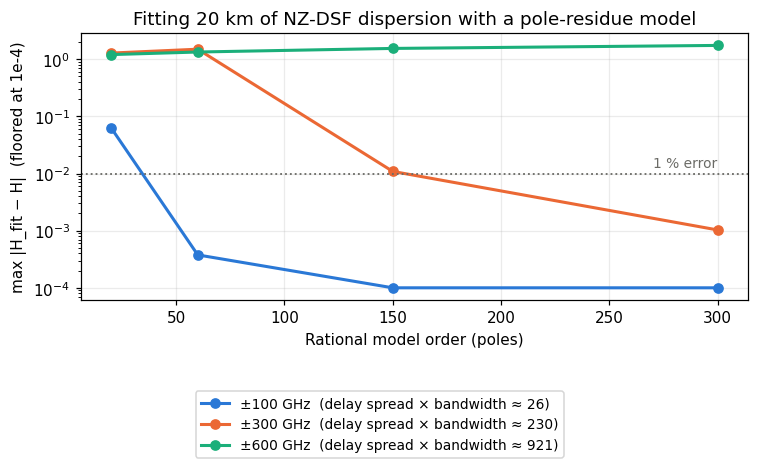

In [7]:
fiber_nzdsf = SplitStepFiber(None, length_km=20, D_ps_nm_km=4.0, S_ps_nm2_km=0, gamma_W_km=0,
                             reference_wavelength=LAM_REF)
spans = [100e9, 300e9, 600e9]
orders = [20, 60, 150, 300]
fit_error = {span: [] for span in spans}
tbp = {}
tic = time.time()
for span in spans:
    f = F_CENTER + np.linspace(-span, span, 3000)
    w = 2 * np.pi * (f - F_CENTER)
    tau_b = abs(fiber_nzdsf.beta2) * fiber_nzdsf.length * w.max() * 1.05
    H = np.exp(1j * (fiber_nzdsf.beta2 / 2 * w**2 * fiber_nzdsf.length + w * tau_b))[:, None, None]
    tbp[span] = abs(fiber_nzdsf.beta2) * fiber_nzdsf.length * (2 * w.max()) * (2 * span)
    for order in orders:
        poles, residues, feedthrough, _ = vector_fitting_discrete(
            order, jnp.asarray(H), jnp.asarray(f), F_CENTER, 1 / DT, sign_convention=PHYSICIST)
        H_fit = np.asarray(pole_residue_response_discrete(jnp.asarray(f), F_CENTER, 1 / DT,
                                                          poles, residues, feedthrough))
        fit_error[span].append(np.max(np.abs(H_fit[:, 0, 0] - H[:, 0, 0])))
timings["rational-fit experiment (12 fits)"] = time.time() - tic

fig, ax = plt.subplots(figsize=(7, 4.2))
for span, color in zip(spans, [BLUE, ORANGE, AQUA]):
    ax.semilogy(orders, np.maximum(fit_error[span], 1e-4), "o-", color=color,
                label=f"±{span/1e9:.0f} GHz  (delay spread × bandwidth ≈ {tbp[span]:.0f})")
ax.axhline(0.01, color=GRAY, ls=":", lw=1.2)
ax.text(orders[-1], 0.013, "1 % error", color=GRAY, fontsize=9, ha="right")
ax.set(xlabel="Rational model order (poles)", ylabel="max |H_fit − H|  (floored at 1e-4)",
       title="Fitting 20 km of NZ-DSF dispersion with a pole-residue model")
fig.legend(loc="lower center", ncol=1, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=(0, 0.2, 1, 1))
plt.show()

At the ±600 GHz this WDM link occupies, even 300 poles do not converge. That is for a single linear, one-port section.

With Kerr, the nonlinearity has to be interleaved with dispersion along the fiber. The step-size rules above need **49 (DSF) to 3,252 (NZ-DSF) sections** for this link at 0 dBm per laser. A continuous-time netlist would therefore need thousands of cascaded (rational dispersion + nonlinear) sections. An envelope resolving about 1 THz needs time steps of about 0.1 ps, so that means over a hundred thousand implicit Newton steps across 12.7 ns, each solving a system with tens of thousands of unknowns.

The split-step method does the same physics with two FFTs per section on a sampled block. That is the practical gap: not impossibility in principle, but orders of magnitude in cost and model-building effort.

The silicon rings are the opposite case. Their memory is short (a photon lifetime of about 6 ps), so a 20th-order $z$-domain fit captures them. Both kinds of model live in the same block-mode netlist.

## 6. SiEPIC microring (de)multiplexers

Each add-drop ring is built from two SiEPIC EBeam `half_ring` couplers (gap 100 nm, R = 10 µm, 500 × 220 nm strip) and two SiEPIC `waveguide` arms (3 dB/cm). This gives FSR ≈ 1.16 THz (about 9.3 nm) and FWHM ≈ 28 GHz.

(The gap-150 nm data file is not passive: its drop port exceeds unity, so it is not used.)

Each ring is tuned onto its channel by choosing the arm length. The same four designs serve as the transmitter multiplexer (add → thru) and the receiver demultiplexer (in → drop).

arm lengths (µm): [6.1969 0.7477 5.7497 1.8989]


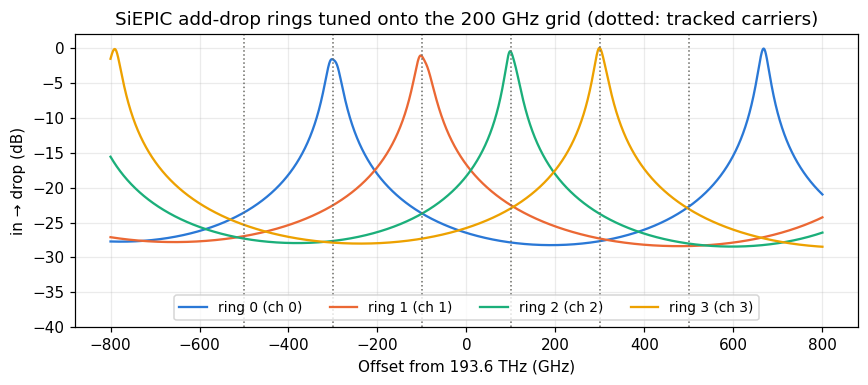

In [8]:
RING_NETLIST = {
    "instances": {"top": "hr", "bot": "hr", "arm_a": "wg", "arm_b": "wg"},
    "connections": {"top,port_2": "arm_a,o0", "arm_a,o1": "bot,port_4",
                    "bot,port_2": "arm_b,o0", "arm_b,o1": "top,port_4"},
    "ports": {"in": "top,port_1", "thru": "top,port_3", "add": "bot,port_1", "drop": "bot,port_3"},
}
HALF_RING = {"gap": 100, "radius": 10}
ARM_LOSS_DB_CM = 3.0
ring_sax, _ = sax.circuit(RING_NETLIST, {"hr": lambda wl=1.55: half_ring(wl=wl, **HALF_RING),
                                         "wg": waveguide})


def ring_response(arm, freqs):
    arms = {"length": arm, "loss": ARM_LOSS_DB_CM}
    return ring_sax(wl=C0 / np.asarray(freqs) * 1e6, arm_a=arms, arm_b=arms)


def tune_arm(f_target):
    # arm length (both arms) that puts a resonance on f_target: minimise the thru power
    thru = lambda a: float(np.abs(ring_response(a, [f_target])[("in", "thru")][0]) ** 2)
    grid = np.linspace(0, 6.5, 131)
    a0 = grid[np.argmin([thru(a) for a in grid])]
    return minimize_scalar(thru, bounds=(max(0, a0 - 0.1), a0 + 0.1), method="bounded",
                           options={"xatol": 1e-5}).x


tic = time.time()
ARMS = [tune_arm(f) for f in CHANNEL_FREQS]
timings["ring tuning (SAX)"] = time.time() - tic
print("arm lengths (µm):", np.round(ARMS, 4))

f_plot = F_CENTER + np.linspace(-0.8e12, 0.8e12, 6001)
fig, ax = plt.subplots(figsize=(8, 3.6))
for k, (arm, color) in enumerate(zip(ARMS, CHANNEL_COLORS)):
    drop = np.abs(np.asarray(ring_response(arm, f_plot)[("in", "drop")])) ** 2
    ax.plot((f_plot - F_CENTER) / 1e9, 10 * np.log10(drop), color=color, lw=1.5, label=f"ring {k} (ch {k})")
for f_slot in SLOT_FREQS:
    ax.axvline((f_slot - F_CENTER) / 1e9, color=GRAY, ls=":", lw=1)
ax.set(xlabel="Offset from 193.6 THz (GHz)", ylabel="in → drop (dB)", ylim=(-40, 2),
       title="SiEPIC add-drop rings tuned onto the 200 GHz grid (dotted: tracked carriers)")
ax.legend(ncol=4, loc="lower center", fontsize=9)
plt.tight_layout()
plt.show()

### Rings in block mode: fusing turns a feedback loop into one IIR filter

A ring is a loop: `top → arm_a → bot → arm_b → top`. Block mode evaluates components in topological order, so a netlist of half-rings and waveguides has no valid order. Passing **`fuse_s_parameters=True`** makes the circuit fuse every connected group of SAX elements that share an `s_parameter_group` into one `SParameterElement`. SAX composes the loop exactly, and the result is vector-fitted **once** in the $z$-domain. Each ring gets its own group id so that neighboring rings on the bus stay separate elements.

The fit covers ±0.8 THz around 193.6 THz. The plot below compares the fitted model with SAX across the **entire** Nyquist zone (±1 THz).

max |pole| = 0.9899 (stable)


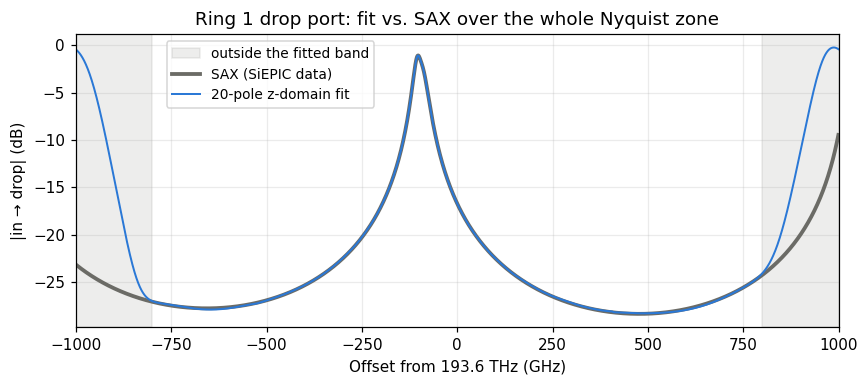

In [9]:
VECTOR_FIT = {
    "model_order": 20,
    "num_frequency_samples": 800,
    "center_wavelength": C0 / F_CENTER,
    "spectral_range": (C0 / (F_CENTER + 0.8e12), C0 / (F_CENTER - 0.8e12)),
}


def ring_model(arm):
    def ring(wl=1.55):
        arms = {"length": arm, "loss": ARM_LOSS_DB_CM}
        return ring_sax(wl=wl, arm_a=arms, arm_b=arms)
    return ring


demo = optical_s_parameter(ring_model(ARMS[1]),
                           {"in": "input", "thru": "output", "drop": "output", "add": "output"})(
    params, vector_fitting_parameters=VECTOR_FIT)
ss = demo._state_space(params)
A_, B_, C_, D_ = (np.asarray(ss[k]) for k in "ABCD")
f_zone = F_CENTER + np.linspace(-0.999, 0.999, 4001) / (2 * DT)
z = np.exp(-1j * 2 * np.pi * (f_zone - F_CENTER) * DT)
H_fit = np.einsum("qn,fn,nm->fqm", C_, 1 / (z[:, None] - np.diag(A_)[None, :]), B_) + D_[None]
ref = ring_response(ARMS[1], f_zone)
drop_row = [p.split("@")[0] for p in ss["output_ports"]].index("drop")
print(f"max |pole| = {np.max(np.abs(np.diag(A_))):.4f} (stable)")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.axvspan(-1000, -800, color=GRAY, alpha=0.12)
ax.axvspan(800, 1000, color=GRAY, alpha=0.12, label="outside the fitted band")
ax.plot((f_zone - F_CENTER) / 1e9, 20 * np.log10(np.abs(np.asarray(ref[("in", "drop")]))),
        color=GRAY, lw=2.5, label="SAX (SiEPIC data)")
ax.plot((f_zone - F_CENTER) / 1e9, 20 * np.log10(np.abs(H_fit[:, drop_row, 0])), color=BLUE,
        lw=1.3, label="20-pole z-domain fit")
ax.set(xlabel="Offset from 193.6 THz (GHz)", ylabel="|in → drop| (dB)", xlim=(-1000, 1000),
       title="Ring 1 drop port: fit vs. SAX over the whole Nyquist zone")
ax.legend(loc="upper left", bbox_to_anchor=(0.11, 1.0), fontsize=9)
plt.tight_layout()
plt.show()

Inside the fitted band the model follows SAX closely (maximum error about 0.05-0.08 near resonance). **Outside it the model is unconstrained**, and there the fitted gain reaches roughly 25-35 dB.

This is the main discrete-time pitfall this notebook ran into. A $z$-domain model is periodic in frequency, so any signal content in the gray strips gets amplified. In the first version of this link, after four cascaded demux rings, it had amplified start-up transients by more than 100 dB. Fitting the whole zone does not help either: the ring's FSR-periodic response is not periodic in $f_s$, so the fit has to straddle a wrap discontinuity, and its in-band error rises to about 1.

The fix is to never drive a fitted model outside its band, which is how real signals behave anyway:
* **Band-limited drivers.** Gaussian-filtered NRZ has no content hundreds of GHz from its carrier.
* **Burst lasers with dark guards.** There is no instantaneous turn-on step. Because the circular fiber only wraps darkness across t = 0, every IIR filter also starts from rest. A filter starting from zero state while its input is already on sees a truncated input, and truncation is broadband.
* **Smooth carrier split in the fiber.** The raised-cosine partition has no Gibbs ripple.

With these in place, the out-of-band energy fraction stays around 1e-5 after all eight rings.

## 7. The link

The netlist is flat and written by hand below:

```
laser k ─▶ EAM k ◀─ PRBS driver k                    (k = 0..3)
               │
               ▼ add
bus:  [mux ring 0] ─thru─▶ [mux 1] ─▶ [mux 2] ─▶ [mux 3] ─▶ fiber ─▶ [demux 0] ─▶ [demux 1] ─▶ [demux 2] ─▶ [demux 3]
                                                                         │drop       │drop        │drop        │drop
                                                                         ▼           ▼            ▼            ▼
                                                                       PD 0        PD 1         PD 2         PD 3
```

Settings:
* each transmitter uses the same PRBS7 pattern, shifted by 31 bits per channel;
* the EAM has a 10 dB extinction ratio: absorption $= 10(1 - V)$ dB for $V \in [0, 1]$;
* the photodiodes have 1 A/W responsivity, 20 pA/√Hz thermal noise and 7.5 GHz bandwidth.

Port directionality comes from the connection order, as usual. The rings' add, in, thru and drop roles follow from how they are wired. With `fuse_s_parameters=True`, the 32 SAX instances collapse into 8 fitted ring elements.

In [10]:
BASE_PATTERN = prbs(7, N_BITS, seed=1)
CHANNEL_BITS = [np.roll(BASE_PATTERN, 31 * k) for k in range(4)]

FIBERS = {
    "NZ-DSF": dict(length_km=20, alpha_db_km=0.2, D_ps_nm_km=4.0, S_ps_nm2_km=0.05,
                   gamma_W_km=1.5, reference_wavelength=C0 / F_CENTER),
    "DSF": dict(length_km=20, alpha_db_km=0.2, D_ps_nm_km=0.0, S_ps_nm2_km=0.075,
                gamma_W_km=2.0, reference_wavelength=C0 / F_CENTER),
}


def add_ring(instances, connections, settings, name, arm, group):
    for part, model in (("top", "hr"), ("bot", "hr"), ("arm_a", "wg"), ("arm_b", "wg")):
        instances[f"{name}_{part}"] = model
        sax_settings = dict(HALF_RING) if model == "hr" else {"length": arm, "loss": ARM_LOSS_DB_CM}
        settings[f"{name}_{part}"] = {"sax_settings": sax_settings,
                                      "vector_fitting_parameters": VECTOR_FIT,
                                      "s_parameter_group": group}
    for src, dst in RING_NETLIST["connections"].items():
        (a, p), (b, q) = src.split(","), dst.split(",")
        connections[f"{name}_{a},{p}"] = f"{name}_{b},{q}"
    return {port: f"{name}_{d.split(',')[0]},{d.split(',')[1]}" for port, d in RING_NETLIST["ports"].items()}


def build_link(laser_power_dbm, fiber_settings):
    instances, connections, settings, ports = {}, {}, {}, {}
    mux = [add_ring(instances, connections, settings, f"mux{k}", ARMS[k], k + 1) for k in range(4)]
    demux = [add_ring(instances, connections, settings, f"demux{k}", ARMS[k], k + 11) for k in range(4)]
    for k in range(4):
        instances.update({f"laser{k}": "laser", f"eam{k}": "eam", f"driver{k}": "driver", f"pd{k}": "pd"})
        settings[f"laser{k}"] = {"wavelength": C0 / CHANNEL_FREQS[k],
                                 "power": 1e-3 * 10 ** (laser_power_dbm / 10)}
        settings[f"eam{k}"] = {"absorption_coefficients": jnp.array([0.0, 0.0, -10.0, 10.0]),
                               "phase_coefficients": jnp.zeros(4)}
        settings[f"driver{k}"] = {"envelope_fn": nrz_envelope_fn(CHANNEL_BITS[k], BIT_RATE, 7e9)}
        settings[f"pd{k}"] = {"seed": k}
        connections[f"laser{k},o0"] = f"eam{k},o0"
        connections[f"driver{k},e0"] = f"eam{k},e0"
        connections[f"eam{k},o1"] = mux[k]["add"]
        connections[demux[k]["drop"]] = f"pd{k},o0"
        ports[f"rx{k}"] = f"pd{k},e0"
    for k in range(3):
        connections[mux[k]["thru"]] = mux[k + 1]["in"]
        connections[demux[k]["thru"]] = demux[k + 1]["in"]
    instances["fiber"] = "fiber"
    settings["fiber"] = fiber_settings
    connections[mux[3]["thru"]] = "fiber,o0"
    connections["fiber,o1"] = demux[0]["in"]
    ports["launch"] = "fiber,o0"
    models = {"hr": half_ring, "wg": waveguide, "laser": BurstCWLaser, "eam": DirectedOpticalModulator,
              "driver": VoltageSource, "pd": Photodetector, "fiber": SplitStepFiber}
    return Circuit({"instances": instances, "connections": connections, "ports": ports}, models), settings


def run_link(laser_power_dbm, fiber_name):
    circuit, settings = build_link(laser_power_dbm, FIBERS[fiber_name])
    sim = BlockModeSimulation(circuit, settings, simulation_parameters=params, fuse_s_parameters=True)
    tic = time.time()
    result = sim.run()
    elapsed = time.time() - tic
    fiber = sim._instantiated_circuit.instantiated_flat_netlist["instances"]["fiber"]["model"]
    launch = np.asarray(result.input_signals["launch"].amplitude[:, :, 0])
    return {
        "rx": [np.asarray(result.output_signals[f"rx{k}"].voltage).real for k in range(4)],
        "launch_dbm": 10 * np.log10(np.mean(np.abs(launch[:, CHANNEL_SLOTS]) ** 2, axis=0)) + 30,
        "fiber_in": fiber.last_input_field, "fiber_out": fiber.last_output_field,
        "fiber_steps": fiber.last_n_steps, "seconds": elapsed, "sim": sim,
    }

8 fused ring elements: ['s_parameter_group_11_0', 's_parameter_group_12_0', 's_parameter_group_13_0', 's_parameter_group_14_0', 's_parameter_group_1_0', 's_parameter_group_2_0', 's_parameter_group_3_0', 's_parameter_group_4_0']
link simulated in 34.0 s; fiber used 3252 split steps
per-channel launch power (dBm): [-5.52 -5.11 -4.22 -3.93]


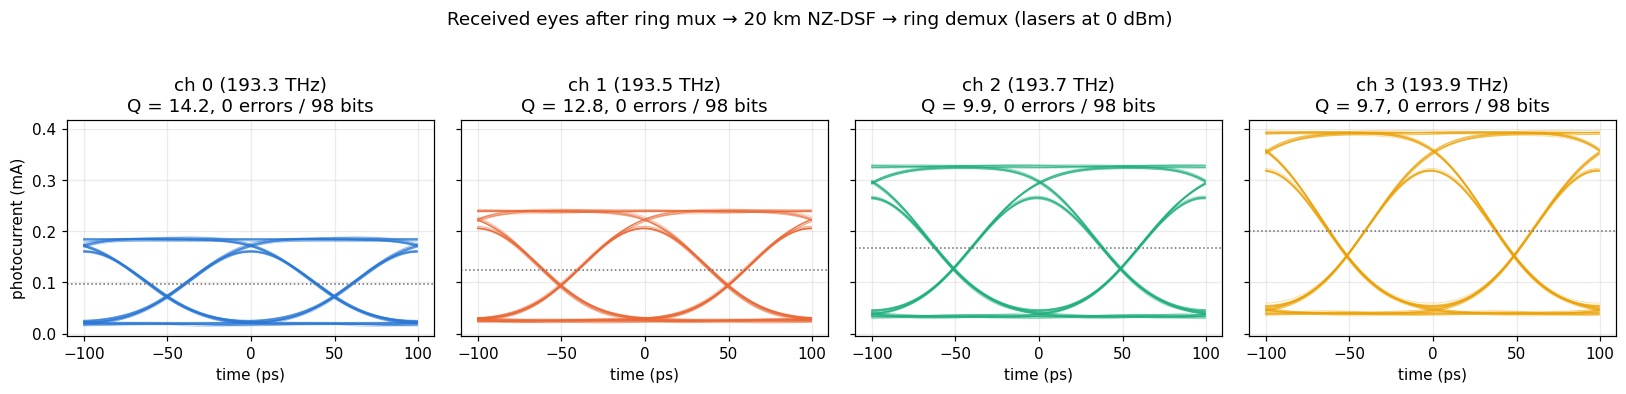

In [11]:
KEEP = slice(14, 112)   # bits well clear of the burst ramps and guards


def analyze(v, bits):
    # Best sampling phase (max Q), mid-level threshold, and errors vs. the transmitted bits.
    x = v.reshape(N_BITS, SAMPLES_PER_BIT)
    best = None
    for phase in range(SAMPLES_PER_BIT):
        s = x[KEEP, phase]
        thr = 0.5 * (s.max() + s.min())
        one, zero = s[s > thr], s[s <= thr]
        if len(one) < 2 or len(zero) < 2:
            continue
        Q = (one.mean() - zero.mean()) / (one.std() + zero.std())
        if best is None or Q > best["Q"]:
            best = {"Q": Q, "phase": phase, "threshold": 0.5 * (one.mean() + zero.mean())}
    decisions = (x[KEEP, best["phase"]] > best["threshold"]).astype(int)
    best["errors"] = min(np.sum(decisions != np.roll(bits, s)[KEEP]) for s in range(-3, 4))
    best["ber_estimate"] = 0.5 * erfc(best["Q"] / np.sqrt(2))
    return best


def plot_eye(ax, v, result, color, title):
    shift = result["phase"] - SAMPLES_PER_BIT
    v = np.roll(v, -shift)
    t_eye = (np.arange(2 * SAMPLES_PER_BIT) - SAMPLES_PER_BIT) * DT * 1e12
    for n in range(KEEP.start, KEEP.stop - 1):
        ax.plot(t_eye, v[n * SAMPLES_PER_BIT: (n + 2) * SAMPLES_PER_BIT] * 1e3, color=color, lw=0.6, alpha=0.35)
    ax.axhline(result["threshold"] * 1e3, color=GRAY, ls=":", lw=1)
    ax.set(title=f"{title}\nQ = {result['Q']:.1f}, {result['errors']} errors / {KEEP.stop - KEEP.start} bits",
           xlabel="time (ps)", ylabel="photocurrent (mA)")


baseline = run_link(0.0, "NZ-DSF")
timings["one link simulation (NZ-DSF, 0 dBm)"] = baseline["seconds"]
elements = baseline["sim"]._instantiated_circuit.instantiated_flat_netlist["instances"]
fused = sorted(name for name in elements if name.startswith("s_parameter_group"))
print(f"{len(fused)} fused ring elements: {fused}")
print(f"link simulated in {baseline['seconds']:.1f} s; fiber used {baseline['fiber_steps']} split steps")
print("per-channel launch power (dBm):", np.round(baseline["launch_dbm"], 2))

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharey=True)
for k, ax in enumerate(axes):
    r = analyze(baseline["rx"][k], CHANNEL_BITS[k])
    plot_eye(ax, baseline["rx"][k], r, CHANNEL_COLORS[k], f"ch {k} ({CHANNEL_FREQS[k]/1e12:.1f} THz)")
    if k:
        ax.set_ylabel("")
fig.suptitle("Received eyes after ring mux → 20 km NZ-DSF → ring demux (lasers at 0 dBm)", y=1.04)
plt.tight_layout()
plt.show()

### FWM on dispersion-shifted fiber vs. NZ-DSF

Now the laser power is swept on both fibers. On DSF the channels sit at zero dispersion, so FWM is phase-matched, and the products $f_i + f_j - f_k$ of the equally spaced grid fall exactly on the channels. There they beat coherently with the data.

On NZ-DSF, D = 4 ps/nm/km detunes the same processes by $\Delta\beta L \gg 1$.

In [12]:
LASER_POWERS_DBM = [-12, -6, -2, 2, 6, 10]
sweep = {}
tic = time.time()
for fiber_name in FIBERS:
    for p_dbm in LASER_POWERS_DBM:
        r = run_link(p_dbm, fiber_name)
        r["analysis"] = [analyze(r["rx"][k], CHANNEL_BITS[k]) for k in range(4)]
        r.pop("sim")
        sweep[fiber_name, p_dbm] = r
        print(f"{fiber_name:6s} laser {p_dbm:+3d} dBm → launch {np.mean(r['launch_dbm']):+5.1f} dBm/ch, "
              f"Q = {[float(round(a['Q'], 1)) for a in r['analysis']]}, errors = {[int(a['errors']) for a in r['analysis']]}, "
              f"{r['fiber_steps']} steps, {r['seconds']:.0f} s")
timings["power sweep (12 link simulations)"] = time.time() - tic

NZ-DSF laser -12 dBm → launch -16.7 dBm/ch, Q = [2.6, 3.8, 4.1, 4.4], errors = [0, 0, 0, 0], 3252 steps, 28 s


NZ-DSF laser  -6 dBm → launch -10.7 dBm/ch, Q = [8.5, 9.5, 8.2, 8.5], errors = [0, 0, 0, 0], 3252 steps, 30 s


NZ-DSF laser  -2 dBm → launch  -6.7 dBm/ch, Q = [12.8, 12.2, 9.6, 9.5], errors = [0, 0, 0, 0], 3252 steps, 29 s


NZ-DSF laser  +2 dBm → launch  -2.7 dBm/ch, Q = [15.1, 13.1, 10.0, 9.8], errors = [0, 0, 0, 0], 3252 steps, 29 s


NZ-DSF laser  +6 dBm → launch  +1.3 dBm/ch, Q = [15.9, 13.3, 10.2, 10.0], errors = [0, 0, 0, 0], 3252 steps, 29 s


...

DSF    laser  -6 dBm → launch -10.7 dBm/ch, Q = [8.1, 9.8, 8.1, 8.7], errors = [0, 0, 0, 0], 49 steps, 19 s


DSF    laser  -2 dBm → launch  -6.7 dBm/ch, Q = [11.4, 11.1, 9.2, 9.8], errors = [0, 0, 0, 0], 49 steps, 20 s


DSF    laser  +2 dBm → launch  -2.7 dBm/ch, Q = [8.7, 8.0, 8.4, 9.1], errors = [0, 0, 0, 0], 49 steps, 20 s


DSF    laser  +6 dBm → launch  +1.3 dBm/ch, Q = [4.5, 3.5, 6.3, 6.5], errors = [0, 24, 0, 0], 101 steps, 20 s


DSF    laser +10 dBm → launch  +5.3 dBm/ch, Q = [2.3, 4.4, 4.5, 3.9], errors = [23, 14, 0, 0], 253 steps, 20 s


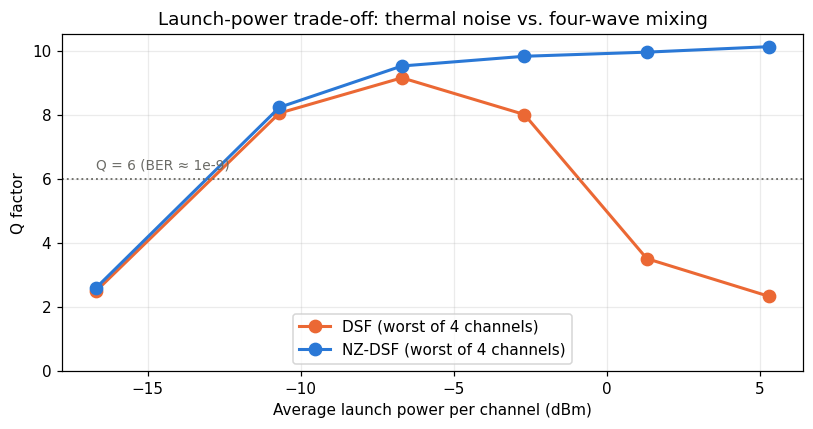

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 4))
for fiber_name, color in (("DSF", ORANGE), ("NZ-DSF", BLUE)):
    launch = [np.mean(sweep[fiber_name, p]["launch_dbm"]) for p in LASER_POWERS_DBM]
    q_worst = [min(a["Q"] for a in sweep[fiber_name, p]["analysis"]) for p in LASER_POWERS_DBM]
    ax.plot(launch, q_worst, "o-", color=color, ms=8, label=f"{fiber_name} (worst of 4 channels)")
ax.axhline(6, color=GRAY, ls=":", lw=1.2)
ax.text(launch[0], 6.3, "Q = 6 (BER ≈ 1e-9)", color=GRAY, fontsize=9)
ax.set_ylim(0, None)
ax.set(xlabel="Average launch power per channel (dBm)", ylabel="Q factor",
       title="Launch-power trade-off: thermal noise vs. four-wave mixing")
ax.legend(loc="lower center")
plt.tight_layout()
plt.show()

At low power both fibers are limited by receiver thermal noise, and Q rises with launch power. Above about −5 dBm per channel the two diverge. On DSF, Q collapses as on-grid FWM products grow roughly as $P^3$, and bit errors appear from about +1 dBm per channel. FWM crosstalk is deterministic and pattern-dependent rather than Gaussian, so the Q factor understates it: a channel can show tens of errors at Q ≈ 3.5. The error counts are the more honest metric here. On NZ-DSF, Q saturates, limited only by the rings' inter-symbol interference and crosstalk.

The spectra make the mechanism visible. The wideband field that the fiber computes internally shows the FWM comb on and around the grid, including the two idler slots.

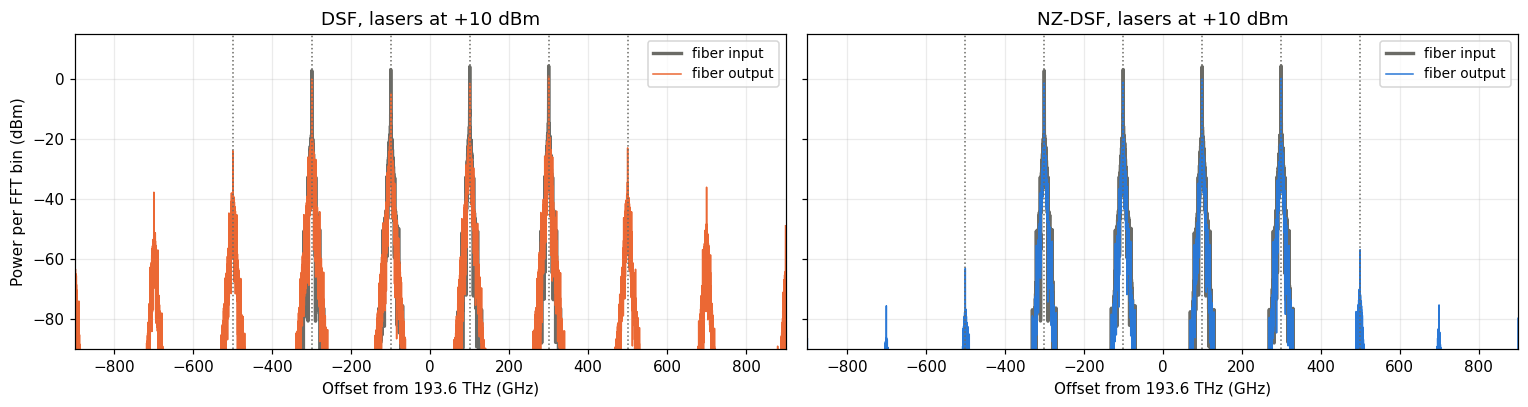

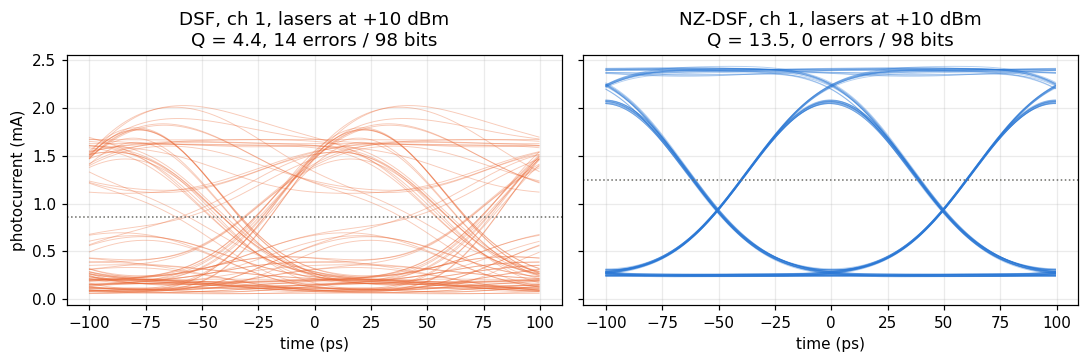

In [14]:
p_hi = LASER_POWERS_DBM[-1]
freq_axis = np.fft.fftshift(np.fft.fftfreq(T, DT)) / 1e9
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), sharey=True)
for ax, fiber_name, color in zip(axes, ("DSF", "NZ-DSF"), (ORANGE, BLUE)):
    r = sweep[fiber_name, p_hi]
    for field, c, lw, label in ((r["fiber_in"], GRAY, 2.2, "fiber input"),
                                (r["fiber_out"], color, 1.0, "fiber output")):
        spectrum = np.fft.fftshift(np.abs(np.fft.ifft(field)) ** 2)   # W per 78.7 MHz bin
        ax.plot(freq_axis, 10 * np.log10(spectrum + 1e-30) + 30, color=c, lw=lw, label=label)
    for f_slot in SLOT_FREQS:
        ax.axvline((f_slot - F_CENTER) / 1e9, color=GRAY, ls=":", lw=1)
    ax.set(xlim=(-900, 900), ylim=(-90, 15), xlabel="Offset from 193.6 THz (GHz)",
           title=f"{fiber_name}, lasers at {p_hi:+d} dBm")
    ax.legend(loc="upper right", fontsize=9)
axes[0].set_ylabel("Power per FFT bin (dBm)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
for ax, fiber_name, color in zip(axes, ("DSF", "NZ-DSF"), (ORANGE, BLUE)):
    r = sweep[fiber_name, p_hi]
    plot_eye(ax, r["rx"][1], r["analysis"][1], color, f"{fiber_name}, ch 1, lasers at {p_hi:+d} dBm")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

## 8. Summary

**What was simulated:** a four-channel, 10 Gb/s silicon-photonic WDM link.
* SiEPIC microring multiplexer and demultiplexer: 32 SAX instances fused into 8 stable 20-pole $z$-domain IIR elements.
* 20 km of nonlinear, dispersive fiber solved by split-step Fourier, with every channel and FWM product carried on a shared 2 THz sampled grid.
* Photodetection, eye diagrams and error counts, all in one block-mode netlist.

It reproduces the classic FWM penalty of equally spaced channels on DSF, and the fiber model agrees with closed-form dispersion, SPM and FWM results to within 0.6 dB.

**Why discrete time made it practical:**
* **Block operators.** Dispersion and Kerr propagation are FFTs over the sampled block, with no rational approximation. Section 5 showed that a pole-residue model of just the linear fiber would need more than 300 poles across this band, and the nonlinearity needs thousands of interleaved sections.
* **Multi-carrier signals.** Six carriers share one time grid. One ring fit serves all of them, through per-carrier pole rotation, and the fiber recombines them wherever the channels interact.
* **Exact recurrences.** Each fitted element is a linear recurrence evaluated by a JAX scan: no Newton iterations, no step-size control, and cost linear in the number of samples.

**What discrete time costs, handled explicitly here:**
* a carrier grid commensurate with the block;
* band-limited sources with guard intervals;
* fits that are only ever driven inside their band;
* a split-step size that respects the FWM coherence length.

**Where a continuous-time solver like circulax is the better tool:**
* stiff, multi-rate mixed-signal electronics (adaptive implicit steps);
* DC, AC and harmonic-balance analysis;
* gradients through a nonlinear transient solve;
* passivity-enforced fitting.

**Natural next steps:**
* Add silicon's own nonlinearity (two-photon and free-carrier absorption) to the rings in sample mode [Lin 2007]. At +10 dBm per channel, ring-enhanced intensities make this significant.
* Use the backward pass to include ring and grating back-reflections.
* Try unequal channel spacing [Forghieri 1995]. This needs a non-uniform partition of the carriers in `SplitStepFiber`.

### References
* K. Inoue, "Four-wave mixing in an optical fiber in the zero-dispersion wavelength region," *J. Lightwave Technol.* 10(11), 1553-1561 (1992).
* R. W. Tkach, A. R. Chraplyvy, F. Forghieri, A. H. Gnauck, R. M. Derosier, "Four-photon mixing and high-speed WDM systems," *J. Lightwave Technol.* 13(5), 841-849 (1995).
* F. Forghieri, R. W. Tkach, A. R. Chraplyvy, "WDM systems with unequally spaced channels," *J. Lightwave Technol.* 13(5), 889-897 (1995).
* G. P. Agrawal, *Nonlinear Fiber Optics* (Academic Press): the NLSE and the split-step Fourier method.
* G. Bosco, A. Carena, V. Curri, R. Gaudino, P. Poggiolini, S. Benedetto, "Suppression of spurious tones induced by the split-step method in fiber systems simulation," *IEEE Photon. Technol. Lett.* 12(5), 489-491 (2000).
* B. Gustavsen, A. Semlyen, "Rational approximation of frequency domain responses by vector fitting," *IEEE Trans. Power Delivery* 14(3), 1052-1061 (1999).
* Q. Lin, O. J. Painter, G. P. Agrawal, "Nonlinear optical phenomena in silicon waveguides: modeling and applications," *Opt. Express* 15(25), 16604-16644 (2007).
* circulax: [github.com/gdsfactory/circulax](https://github.com/gdsfactory/circulax) and its [documentation](https://gdsfactory.github.io/circulax/).
* Ansys Lumerical INTERCONNECT: [transient sample/block mode simulator](https://optics.ansys.com/hc/en-us/articles/360034399174-INTERCONNECT-Transient-Sample-Block-Mode-TSM-TBM-Simulator).

In [15]:
for stage, seconds in timings.items():
    print(f"{stage:45s} {seconds:7.1f} s")

FWM validation (7 fiber runs)                    11.8 s
rational-fit experiment (12 fits)                 1.3 s
ring tuning (SAX)                                13.4 s
one link simulation (NZ-DSF, 0 dBm)              34.0 s
power sweep (12 link simulations)               292.8 s
